# Skenario A: BERTopic dengan *Embedding* Umum

**Notebook:** `02_skenario_A_embedding_umum.ipynb`  
**Model Embedding:** `all-MiniLM-L6-v2` (Sentence Transformers)  
**Tahap:** Pemodelan Topik — Skenario A  
**Deskripsi:** Notebook ini menjalankan pipeline BERTopic menggunakan model embedding bersifat umum (*general-purpose*), yaitu `all-MiniLM-L6-v2`. Model ini dilatih pada korpus teks umum yang luas sehingga menghasilkan representasi semantik yang baik secara umum, namun tidak dioptimalkan khusus untuk domain keamanan siber. Hasil dari skenario ini akan dibandingkan dengan Skenario B yang menggunakan embedding domain-spesifik.

**Urutan Pipeline:**  
`Data Bersih` → `Embedding (all-MiniLM-L6-v2)` → `Reduksi Dimensi (UMAP)` → `Klasterisasi (HDBSCAN)` → `Representasi Topik (c-TF-IDF)` → `Hasil Model A`

---

## 0. Persiapan: Import Library & Konfigurasi

In [1]:
# Mengimpor seluruh library yang dibutuhkan untuk pipeline Skenario A.
# Setiap library memiliki peran spesifik dalam alur pemodelan BERTopic.

import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

# Komponen utama BERTopic
from bertopic import BERTopic

# Model embedding umum dari Sentence Transformers
from sentence_transformers import SentenceTransformer

# Komponen reduksi dimensi dan klasterisasi
from umap import UMAP
from hdbscan import HDBSCAN

# Komponen representasi topik
from sklearn.feature_extraction.text import CountVectorizer

warnings.filterwarnings("ignore")
matplotlib.rcParams["figure.dpi"] = 120

print("Library berhasil diimpor.")

import bertopic, sentence_transformers, umap, hdbscan, sklearn
print(f"  bertopic            : {bertopic.__version__}")
print(f"  sentence-transformers: {sentence_transformers.__version__}")
print(f"  umap-learn          : {umap.__version__}")

import importlib.metadata
print(f"  hdbscan             : {importlib.metadata.version('hdbscan')}")

print(f"  scikit-learn        : {sklearn.__version__}")

Library berhasil diimpor.
  bertopic            : 0.17.4
  sentence-transformers: 5.5.1
  umap-learn          : 0.5.12
  hdbscan             : 0.8.43
  scikit-learn        : 1.8.0


In [2]:
# Mendefinisikan path dan parameter konfigurasi global.
# Semua parameter penting dikumpulkan di satu cell ini agar
# mudah dituning tanpa harus menyisir seluruh notebook.

BASE_DIR       = Path("/Users/javierihsan/Javier/S1 UNAIR/skripsi/codingan_skripsi_javier")
PROCESSED_DIR  = BASE_DIR / "data" / "processed"
RESULTS_DIR    = BASE_DIR / "results" / "skenario_A"

# Buat folder hasil jika belum ada
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# ---- Parameter Model ----
NAMA_MODEL_EMBEDDING = "all-MiniLM-L6-v2"

# Parameter UMAP — mengendalikan proses reduksi dimensi
UMAP_N_NEIGHBORS    = 15    # jumlah tetangga lokal yang dipertimbangkan
UMAP_N_COMPONENTS   = 5     # dimensi target setelah reduksi
UMAP_MIN_DIST       = 0.0   # jarak minimum antar titik (0.0 optimal untuk klasterisasi)
UMAP_METRIC         = "cosine"
UMAP_RANDOM_STATE   = 42    # seed untuk reprodusibilitas hasil

# Parameter HDBSCAN — mengendalikan proses klasterisasi
HDBSCAN_MIN_CLUSTER_SIZE    = 10   # ukuran minimum sebuah klaster dianggap valid
HDBSCAN_MIN_SAMPLES         = 5    # kontrol sensitivitas terhadap noise
HDBSCAN_METRIC              = "euclidean"
HDBSCAN_CLUSTER_SELECTION   = "eom"  # eom: excess of mass, cocok untuk klaster padat

# Parameter CountVectorizer — untuk representasi c-TF-IDF
VECTORIZER_NGRAM_RANGE = (1, 2)   # unigram dan bigram
VECTORIZER_MIN_DF      = 2        # abaikan term yang muncul di kurang dari 2 dokumen
VECTORIZER_STOP_WORDS  = "english"

print("Konfigurasi berhasil dimuat.")
print(f"  Model embedding : {NAMA_MODEL_EMBEDDING}")
print(f"  UMAP            : n_neighbors={UMAP_N_NEIGHBORS}, n_components={UMAP_N_COMPONENTS}")
print(f"  HDBSCAN         : min_cluster_size={HDBSCAN_MIN_CLUSTER_SIZE}, min_samples={HDBSCAN_MIN_SAMPLES}")
print(f"  Output dir      : {RESULTS_DIR}")

Konfigurasi berhasil dimuat.
  Model embedding : all-MiniLM-L6-v2
  UMAP            : n_neighbors=15, n_components=5
  HDBSCAN         : min_cluster_size=10, min_samples=5
  Output dir      : /Users/javierihsan/Javier/S1 UNAIR/skripsi/codingan_skripsi_javier/results/skenario_A


---
## 1. Pemuatan Data Bersih

Memuat hasil pra-pemrosesan dari notebook sebelumnya (`01_pra_pemrosesan.ipynb`) sebagai titik awal pipeline Skenario A.

In [3]:
# Membaca file CSV hasil pra-pemrosesan yang telah disimpan sebelumnya.
# Kolom teks_bersih adalah kolom utama yang akan diproses dalam pipeline ini.

path_data_bersih = PROCESSED_DIR / "data_bersih.csv"

if not path_data_bersih.exists():
    raise FileNotFoundError(
        f"File data_bersih.csv tidak ditemukan di {PROCESSED_DIR}.\n"
        "Pastikan notebook 01_pra_pemrosesan.ipynb sudah dijalankan terlebih dahulu."
    )

df = pd.read_csv(path_data_bersih, encoding="utf-8-sig")

print(f"Data berhasil dimuat: {len(df)} dokumen, {len(df.columns)} kolom")
print()
print("Pratinjau 3 baris pertama:")
df[["advisory_id", "teks_bersih", "panjang_teks_bersih"]].head(3)

Data berhasil dimuat: 3461 dokumen, 9 kolom

Pratinjau 3 baris pertama:


,advisory_id,teks_bersih,panjang_teks_bersih
0,ICSA-10-147-01,cisco mediator framework 1.5.1 before 1.5.1.bu...,3321
1,ICSA-10-316-01A,webscada ws100 and ws200 easy connect ec150 mo...,1084
2,ICSA-10-322-01,stack-based buffer overflow in the save method...,424


In [4]:
# Mengekstrak kolom teks_bersih sebagai list Python.
# BERTopic dan Sentence Transformers menerima input berupa list of strings,
# bukan pandas Series, sehingga konversi ini diperlukan.

dokumen = df["teks_bersih"].tolist()

print(f"Total dokumen yang akan diproses : {len(dokumen)}")
print()
print("Contoh dokumen pertama:")
print(dokumen[0][:300], "...")

Total dokumen yang akan diproses : 3461

Contoh dokumen pertama:
cisco mediator framework 1.5.1 before 1.5.1.build.14-eng 2.2 before 2.2.1.dev.1 and 3.0 before 3.0.9.release.1 on the cisco network building mediator nbm-2400 and nbm-4800 and the richards-zeta mediator 2500 has a default password for the administrative user account and unspecified other accounts wh ...


---
## 2. Tahap Embedding dengan `all-MiniLM-L6-v2`

Setiap dokumen dikonversi menjadi vektor numerik berdimensi tinggi yang merepresentasikan makna semantiknya. Model `all-MiniLM-L6-v2` dipilih untuk Skenario A karena merupakan model embedding umum yang ringan, cepat, namun tetap menghasilkan representasi semantik yang baik.

In [5]:
# Memuat model Sentence Transformers all-MiniLM-L6-v2.
# Model akan diunduh otomatis dari HuggingFace Hub pada percobaan pertama
# (~80 MB) dan disimpan di cache lokal untuk penggunaan berikutnya.
#
# Spesifikasi model:
#   - Dimensi output embedding : 384 dimensi
#   - Panjang input maksimum   : 256 token
#   - Dilatih pada             : 1 miliar+ pasangan kalimat umum

print(f"Memuat model embedding: {NAMA_MODEL_EMBEDDING}")
print("(Proses unduhan otomatis jika belum tersedia di cache lokal)")

embedding_model = SentenceTransformer(NAMA_MODEL_EMBEDDING)

print()
print(f"[OK] Model berhasil dimuat.")
print(f"  Dimensi output embedding : {embedding_model.get_sentence_embedding_dimension()}")
print(f"  Panjang input maksimum   : {embedding_model.max_seq_length} token")

Memuat model embedding: all-MiniLM-L6-v2
(Proses unduhan otomatis jika belum tersedia di cache lokal)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


[OK] Model berhasil dimuat.
  Dimensi output embedding : 384
  Panjang input maksimum   : 256 token


encode_dengan_chunking 

In [6]:
# Mendefinisikan fungsi encode_dengan_chunking untuk menangani dokumen
# yang lebih panjang dari batas input model (256 token / ~190 kata).
#
# Strategi yang digunakan: setiap dokumen dipecah menjadi potongan (chunk)
# berukuran ~300 kata dengan overlap 50 kata antar potongan untuk menjaga
# kontinuitas konteks di perbatasan. Tiap chunk di-embed secara independen,
# lalu seluruh vektor chunk dirata-ratakan menjadi satu vektor dokumen
# (mean pooling).
#
# Ini menggantikan pendekatan model.encode(dokumen) yang secara diam-diam
# memotong semua dokumen pada token ke-256 tanpa peringatan — penyebab
# utama distribusi positive skewness ekstrem pada dataset ini.

from tqdm import tqdm

def chunk_teks(teks: str, ukuran_chunk: int = 300, overlap: int = 50) -> list:
    """
    Memecah teks menjadi potongan dengan overlap.
    
    Parameters
    ----------
    teks         : teks lengkap yang akan dipecah
    ukuran_chunk : jumlah kata per potongan (≈256 token BERT)
    overlap      : jumlah kata yang tumpang tindih antar potongan
    
    Returns
    -------
    list of str — satu atau lebih potongan teks
    """
    kata = teks.split()
    if len(kata) <= ukuran_chunk:
        return [teks]
    
    potongan = []
    langkah  = ukuran_chunk - overlap
    for i in range(0, len(kata), langkah):
        segmen = kata[i : i + ukuran_chunk]
        potongan.append(" ".join(segmen))
        if i + ukuran_chunk >= len(kata):
            break
    return potongan


def encode_dengan_chunking(
    dokumen     : list,
    model,
    ukuran_chunk: int = 300,
    overlap     : int = 50,
    batch_size  : int = 32,
) -> np.ndarray:
    """
    Menghasilkan embedding dokumen dengan strategi chunk + mean pooling.
    
    Setiap dokumen dipecah menjadi chunk, tiap chunk di-embed, lalu
    seluruh vektor chunk dirata-ratakan menjadi satu vektor per dokumen.
    Dokumen pendek (< ukuran_chunk kata) diproses dalam satu chunk tunggal
    sehingga tidak ada overhead untuk mayoritas dokumen dalam dataset ini.
    
    Parameters
    ----------
    dokumen      : list teks bersih yang akan di-embed
    model        : model SentenceTransformer yang sudah dimuat
    ukuran_chunk : jumlah kata per chunk
    overlap      : jumlah kata overlap antar chunk
    batch_size   : batch size untuk encoding setiap set chunk
    
    Returns
    -------
    np.ndarray shape (n_dokumen, dimensi_embedding)
    """
    semua_embedding = []
    
    for dok in tqdm(dokumen, desc="Embedding dengan chunking"):
        potongan = chunk_teks(dok, ukuran_chunk, overlap)
        
        # Encode semua chunk dari satu dokumen dalam satu batch
        chunk_embeds = model.encode(
            potongan,
            show_progress_bar=False,
            batch_size=batch_size,
            convert_to_numpy=True,
        )
        
        # Mean pooling: rata-ratakan seluruh chunk → satu vektor dokumen
        embedding_dok = chunk_embeds.mean(axis=0)
        semua_embedding.append(embedding_dok)
    
    return np.array(semua_embedding)


print("Fungsi encode_dengan_chunking berhasil didefinisikan.")
print(f" Ukuran chunk  : 300 kata (~256 token BERT)")
print(f" Overlap       : 50 kata antar potongan")
print(f" Pooling       : mean pooling atas seluruh chunk per dokumen")

Fungsi encode_dengan_chunking berhasil didefinisikan.
 Ukuran chunk  : 300 kata (~256 token BERT)
 Overlap       : 50 kata antar potongan
 Pooling       : mean pooling atas seluruh chunk per dokumen


In [7]:
# Menjalankan proses embedding pada seluruh korpus dengan strategi chunking.
# Berbeda dari pendekatan naive model.encode(dokumen) yang memotong dokumen
# pada token ke-256, pendekatan ini memproses seluruh isi dokumen tanpa
# kehilangan informasi pada dokumen-dokumen panjang.
#
# Dokumen pendek (< 300 kata) tetap diproses dalam satu chunk sehingga
# tidak ada overhead komputasi untuk mayoritas dokumen.
# Dokumen panjang — termasuk outlier dengan 30.000+ kata yang menyebabkan
# positive skewness ekstrem — dipecah, di-embed per chunk, lalu dirata-ratakan.

# Hitung statistik chunk sebelum proses dimulai untuk pelaporan
info_chunk = [len(chunk_teks(d)) for d in dokumen]
dok_multichunk = sum(1 for c in info_chunk if c > 1)

print("Memulai proses embedding dengan chunking...")
print(f" Jumlah dokumen          : {len(dokumen)}")
print(f" Strategi                : chunk (300 kata, overlap 50) + mean pooling")
print(f" Dokumen dengan >1 chunk : {dok_multichunk} ({dok_multichunk/len(dokumen)*100:.1f}%)")
print(f" Rata-rata chunk/dokumen : {sum(info_chunk)/len(info_chunk):.2f}")
print()

embeddings = encode_dengan_chunking(
    dokumen,
    embedding_model,
    ukuran_chunk=300,
    overlap=50,
    batch_size=32,
)

print()
print(f"[OK] Embedding selesai.")
print(f" Bentuk matriks embedding : {embeddings.shape}")
print(f" ({embeddings.shape[0]} dokumen × {embeddings.shape[1]} dimensi)")

Memulai proses embedding dengan chunking...
 Jumlah dokumen          : 3461
 Strategi                : chunk (300 kata, overlap 50) + mean pooling
 Dokumen dengan >1 chunk : 3030 (87.5%)
 Rata-rata chunk/dokumen : 2.92



Embedding dengan chunking: 100%|██████████| 3461/3461 [01:24<00:00, 40.74it/s]


[OK] Embedding selesai.
 Bentuk matriks embedding : (3461, 384)
 (3461 dokumen × 384 dimensi)


In [8]:
# Menyimpan matriks embedding ke disk agar tidak perlu dihitung ulang
# jika ingin menjalankan ulang tahap-tahap berikutnya.
# Format .npy adalah format biner NumPy yang efisien.

path_embeddings = RESULTS_DIR / "embeddings_skenario_A.npy"
np.save(path_embeddings, embeddings)

print(f"Matriks embedding disimpan di:")
print(f"  {path_embeddings}")
print(f"  Ukuran file: {path_embeddings.stat().st_size / (1024**2):.2f} MB")

Matriks embedding disimpan di:
  /Users/javierihsan/Javier/S1 UNAIR/skripsi/codingan_skripsi_javier/results/skenario_A/embeddings_skenario_A.npy
  Ukuran file: 5.07 MB


---
## 3. Tahap Reduksi Dimensi dengan UMAP

Matriks embedding berdimensi 384 direduksi ke dimensi yang lebih rendah menggunakan UMAP (*Uniform Manifold Approximation and Projection*). Reduksi dimensi diperlukan agar algoritma klasterisasi HDBSCAN dapat bekerja secara efektif, karena HDBSCAN kurang optimal pada ruang berdimensi sangat tinggi.

In [9]:
# Menginisialisasi model UMAP dengan parameter yang telah dikonfigurasi.
# random_state ditetapkan untuk memastikan reprodusibilitas hasil —
# penting dalam konteks penelitian ilmiah agar hasil dapat diverifikasi.

print("Menginisialisasi UMAP...")
print(f"  n_neighbors   : {UMAP_N_NEIGHBORS}")
print(f"  n_components  : {UMAP_N_COMPONENTS}")
print(f"  min_dist      : {UMAP_MIN_DIST}")
print(f"  metric        : {UMAP_METRIC}")
print(f"  random_state  : {UMAP_RANDOM_STATE}")

umap_model = UMAP(
    n_neighbors=UMAP_N_NEIGHBORS,
    n_components=UMAP_N_COMPONENTS,
    min_dist=UMAP_MIN_DIST,
    metric=UMAP_METRIC,
    random_state=UMAP_RANDOM_STATE,
    low_memory=False,
)

print()
print("[OK] Model UMAP siap.")

Menginisialisasi UMAP...
  n_neighbors   : 15
  n_components  : 5
  min_dist      : 0.0
  metric        : cosine
  random_state  : 42

[OK] Model UMAP siap.


In [10]:
# Menjalankan reduksi dimensi pada matriks embedding.
# Proses ini memetakan setiap vektor 384 dimensi menjadi vektor 5 dimensi
# dengan mempertahankan struktur topologis data asli sebisa mungkin.

print("Menjalankan reduksi dimensi UMAP...")
print(f"  Input  : {embeddings.shape} dimensi")
print(f"  Target : {UMAP_N_COMPONENTS} dimensi")

embeddings_tereduksi = umap_model.fit_transform(embeddings)

print()
print(f"[OK] Reduksi dimensi selesai.")
print(f"  Bentuk setelah reduksi : {embeddings_tereduksi.shape}")

Menjalankan reduksi dimensi UMAP...
  Input  : (3461, 384) dimensi
  Target : 5 dimensi

[OK] Reduksi dimensi selesai.
  Bentuk setelah reduksi : (3461, 5)


Membuat visualisasi 2D UMAP untuk eksplorasi...


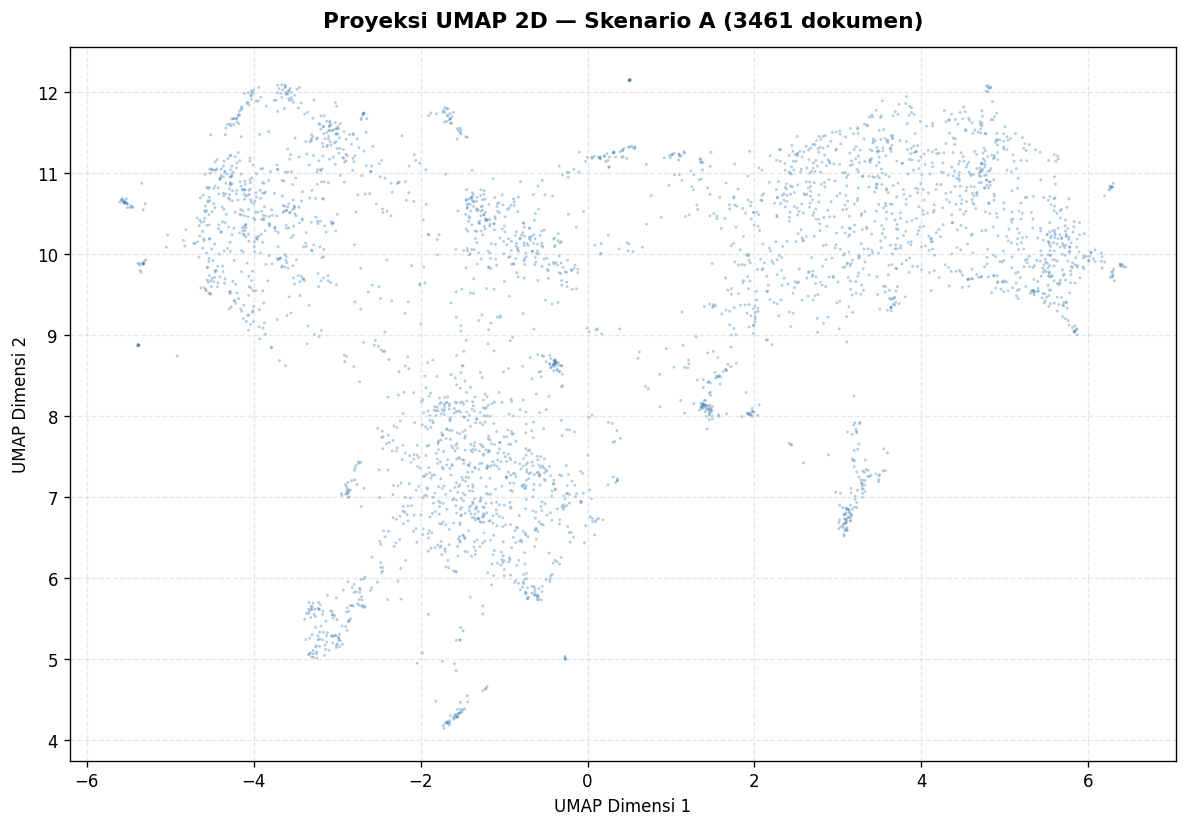

Visualisasi disimpan di: /Users/javierihsan/Javier/S1 UNAIR/skripsi/codingan_skripsi_javier/results/skenario_A/visualisasi_umap_2d_skenario_A.png


In [11]:
# Memvisualisasikan hasil UMAP dalam 2D untuk inspeksi distribusi data.
# Karena UMAP menghasilkan 5 dimensi (untuk HDBSCAN), visualisasi 2D ini
# dibuat dengan menjalankan UMAP terpisah hanya untuk tujuan eksplorasi.
# Hasil visualisasi ini tidak mempengaruhi pipeline pemodelan.

print("Membuat visualisasi 2D UMAP untuk eksplorasi...")

umap_2d = UMAP(
    n_neighbors=UMAP_N_NEIGHBORS,
    n_components=2,
    min_dist=0.1,
    metric=UMAP_METRIC,
    random_state=UMAP_RANDOM_STATE,
    low_memory=False,
)

embeddings_2d = umap_2d.fit_transform(embeddings)

fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    s=3,
    alpha=0.4,
    color="steelblue",
    edgecolors="none",
)

ax.set_title(
    f"Proyeksi UMAP 2D — Skenario A ({len(dokumen)} dokumen)",
    fontsize=13, fontweight="bold", pad=12
)
ax.set_xlabel("UMAP Dimensi 1", fontsize=10)
ax.set_ylabel("UMAP Dimensi 2", fontsize=10)
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
path_viz_umap = RESULTS_DIR / "visualisasi_umap_2d_skenario_A.png"
plt.savefig(path_viz_umap, dpi=150, bbox_inches="tight")
plt.show()

print(f"Visualisasi disimpan di: {path_viz_umap}")

---
## 4. Tahap Klasterisasi dengan HDBSCAN

Hasil reduksi dimensi UMAP dikelompokkan menggunakan HDBSCAN (*Hierarchical Density-Based Spatial Clustering of Applications with Noise*). HDBSCAN dipilih karena kemampuannya mendeteksi klaster dengan bentuk dan kepadatan yang bervariasi, serta secara otomatis mengidentifikasi titik-titik yang dianggap *noise* (diberi label topik -1).

In [12]:
# Menginisialisasi model HDBSCAN.
# prediction_data=True diperlukan agar model dapat melakukan prediksi
# pada dokumen baru di luar data latih (dibutuhkan oleh BERTopic).

print("Menginisialisasi HDBSCAN...")
print(f"  min_cluster_size     : {HDBSCAN_MIN_CLUSTER_SIZE}")
print(f"  min_samples          : {HDBSCAN_MIN_SAMPLES}")
print(f"  metric               : {HDBSCAN_METRIC}")
print(f"  cluster_selection    : {HDBSCAN_CLUSTER_SELECTION}")

hdbscan_model = HDBSCAN(
    min_cluster_size=HDBSCAN_MIN_CLUSTER_SIZE,
    min_samples=HDBSCAN_MIN_SAMPLES,
    metric=HDBSCAN_METRIC,
    cluster_selection_method=HDBSCAN_CLUSTER_SELECTION,
    prediction_data=True,
)

print()
print("[OK] Model HDBSCAN siap.")

Menginisialisasi HDBSCAN...
  min_cluster_size     : 10
  min_samples          : 5
  metric               : euclidean
  cluster_selection    : eom

[OK] Model HDBSCAN siap.


In [13]:
# Menjalankan klasterisasi pada hasil reduksi dimensi UMAP.
# HDBSCAN bekerja langsung pada embeddings_tereduksi (5 dimensi)
# yang telah dihasilkan pada tahap sebelumnya.

print("Menjalankan klasterisasi HDBSCAN...")

hdbscan_model.fit(embeddings_tereduksi)
label_klaster = hdbscan_model.labels_

jumlah_klaster  = len(set(label_klaster)) - (1 if -1 in label_klaster else 0)
jumlah_noise    = (label_klaster == -1).sum()
persen_noise    = jumlah_noise / len(label_klaster) * 100

print()
print(f"[OK] Klasterisasi selesai.")
print(f"  Jumlah klaster terdeteksi : {jumlah_klaster}")
print(f"  Dokumen noise (label -1)  : {jumlah_noise} ({persen_noise:.1f}%)")
print(f"  Dokumen terklaster        : {len(label_klaster) - jumlah_noise}")

Menjalankan klasterisasi HDBSCAN...

[OK] Klasterisasi selesai.
  Jumlah klaster terdeteksi : 62
  Dokumen noise (label -1)  : 1228 (35.5%)
  Dokumen terklaster        : 2233


In [14]:
# Menampilkan distribusi ukuran klaster.
# Distribusi ini memberikan gambaran awal apakah klaster yang terbentuk
# seimbang atau didominasi oleh beberapa klaster besar saja.

label_seri = pd.Series(label_klaster)
distribusi = label_seri[label_seri != -1].value_counts().sort_index()

print(f"Distribusi ukuran klaster (10 klaster terbesar):")
print(distribusi.sort_values(ascending=False).head(10).to_string())
print()
print(f"Statistik ukuran klaster:")
print(distribusi.describe().round(2))

Distribusi ukuran klaster (10 klaster terbesar):
15    249
10    124
0     106
26     88
36     82
23     75
19     69
59     63
58     59
31     59

Statistik ukuran klaster:
count     62.00
mean      36.02
std       36.93
min       10.00
25%       14.00
50%       25.50
75%       43.50
max      249.00
Name: count, dtype: float64


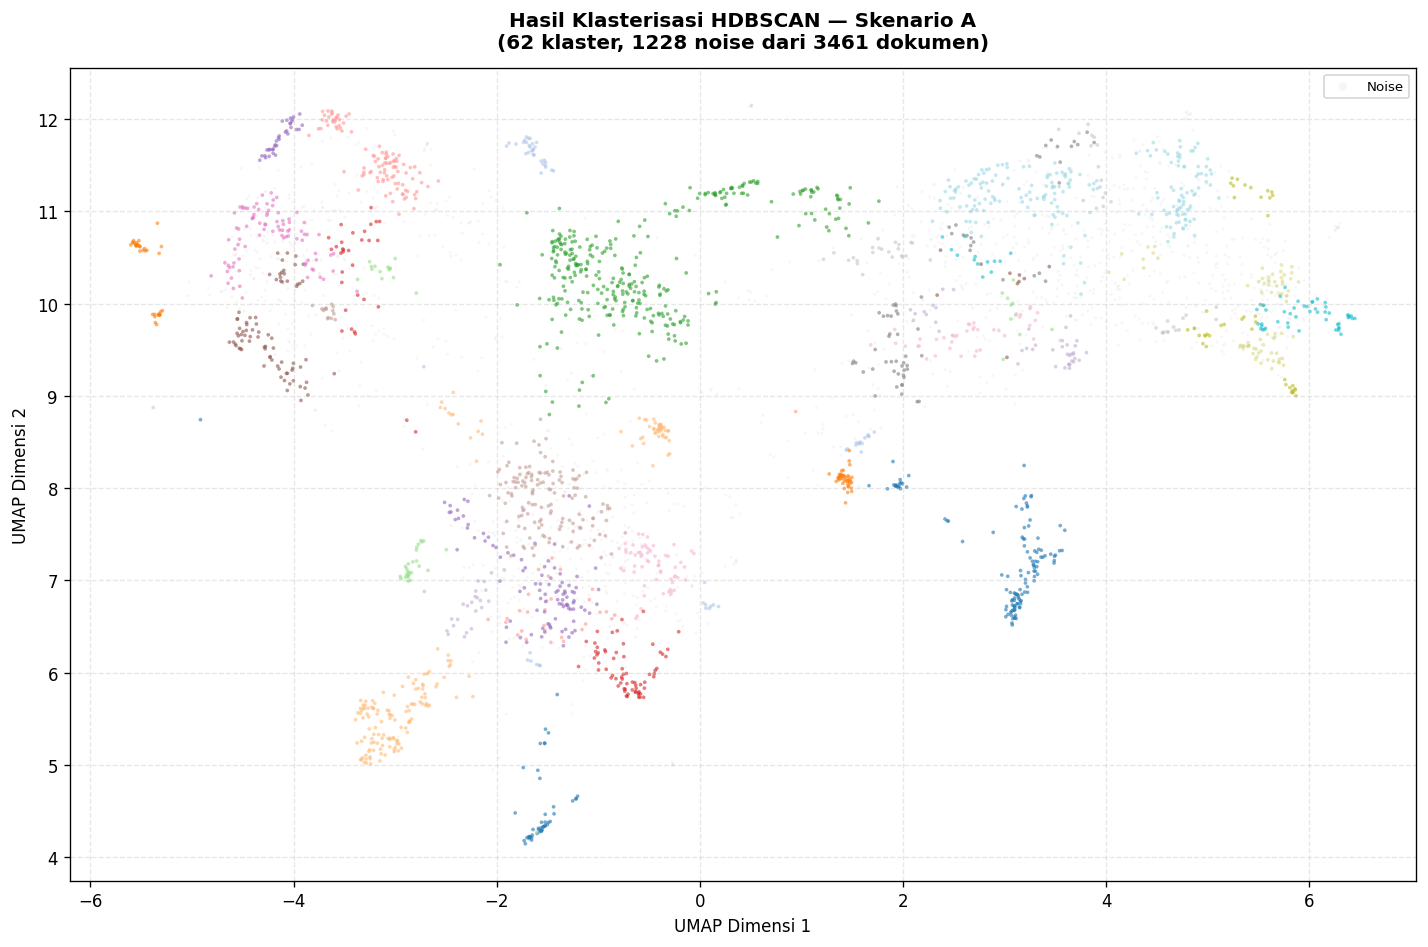

Visualisasi disimpan di: /Users/javierihsan/Javier/S1 UNAIR/skripsi/codingan_skripsi_javier/results/skenario_A/visualisasi_klaster_skenario_A.png


In [15]:
# Memvisualisasikan hasil klasterisasi pada ruang 2D UMAP.
# Setiap warna mewakili satu klaster; titik berwarna abu-abu
# adalah dokumen yang dikategorikan sebagai noise oleh HDBSCAN.

import matplotlib.cm as cm

fig, ax = plt.subplots(figsize=(12, 8))

# Plot dokumen noise terlebih dahulu agar berada di lapisan bawah
mask_noise = label_klaster == -1
ax.scatter(
    embeddings_2d[mask_noise, 0],
    embeddings_2d[mask_noise, 1],
    s=3, alpha=0.2, color="lightgray", label="Noise", edgecolors="none"
)

# Plot setiap klaster dengan warna berbeda
palet_warna = cm.get_cmap("tab20", jumlah_klaster)
for idx_klaster in range(jumlah_klaster):
    mask = label_klaster == idx_klaster
    ax.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        s=5, alpha=0.6,
        color=palet_warna(idx_klaster),
        edgecolors="none"
    )

ax.set_title(
    f"Hasil Klasterisasi HDBSCAN — Skenario A\n"
    f"({jumlah_klaster} klaster, {jumlah_noise} noise dari {len(dokumen)} dokumen)",
    fontsize=12, fontweight="bold", pad=12
)
ax.set_xlabel("UMAP Dimensi 1", fontsize=10)
ax.set_ylabel("UMAP Dimensi 2", fontsize=10)
ax.legend(loc="upper right", fontsize=8, markerscale=3)
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
path_viz_klaster = RESULTS_DIR / "visualisasi_klaster_skenario_A.png"
plt.savefig(path_viz_klaster, dpi=150, bbox_inches="tight")
plt.show()

print(f"Visualisasi disimpan di: {path_viz_klaster}")

---
## 5. Tahap Representasi Topik dengan c-TF-IDF

BERTopic dijalankan secara penuh dengan menggabungkan seluruh komponen yang telah disiapkan. c-TF-IDF (*class-based TF-IDF*) digunakan untuk menghasilkan kata-kata kunci representatif dari setiap topik yang terbentuk.

In [16]:
# Menginisialisasi CountVectorizer yang akan digunakan sebagai
# komponen representasi topik dalam BERTopic.
#
# CountVectorizer menghasilkan representasi bag-of-words yang kemudian
# digunakan oleh BERTopic untuk menghitung c-TF-IDF per topik.
# Penggunaan ngram (1,2) memungkinkan frasa dua kata seperti
# 'remote access' atau 'buffer overflow' tertangkap sebagai fitur.

vectorizer_model = CountVectorizer(
    ngram_range=VECTORIZER_NGRAM_RANGE,
    min_df=VECTORIZER_MIN_DF,
    stop_words=VECTORIZER_STOP_WORDS,
)

print("CountVectorizer siap.")
print(f"  ngram_range : {VECTORIZER_NGRAM_RANGE}")
print(f"  min_df      : {VECTORIZER_MIN_DF}")
print(f"  stop_words  : {VECTORIZER_STOP_WORDS}")

CountVectorizer siap.
  ngram_range : (1, 2)
  min_df      : 2
  stop_words  : english


In [17]:
# Merakit dan menjalankan model BERTopic secara penuh.
# Komponen-komponen yang telah diinisialisasi sebelumnya —
# embedding_model, umap_model, hdbscan_model, dan vectorizer_model —
# dimasukkan ke dalam BERTopic sebagai sub-komponen yang saling terhubung.
#
# Dengan menyediakan embeddings yang sudah dihitung sebelumnya,
# BERTopic tidak perlu menjalankan ulang proses embedding dari awal,
# sehingga menghemat waktu komputasi secara signifikan.

print("Merakit dan menjalankan BERTopic Skenario A...")

topic_model_A = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    top_n_words=10,           # jumlah kata kunci teratas per topik
    verbose=True,
)

# fit_transform menerima dokumen + embedding yang sudah ada
topik, probabilitas = topic_model_A.fit_transform(dokumen, embeddings)

print()
print(f"[OK] BERTopic Skenario A selesai dijalankan.")

2026-05-29 02:37:41,383 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Merakit dan menjalankan BERTopic Skenario A...


2026-05-29 02:37:52,316 - BERTopic - Dimensionality - Completed ✓
2026-05-29 02:37:52,321 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-29 02:37:52,378 - BERTopic - Cluster - Completed ✓
2026-05-29 02:37:52,383 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-29 02:37:53,685 - BERTopic - Representation - Completed ✓



[OK] BERTopic Skenario A selesai dijalankan.


In [18]:
# Menampilkan ringkasan hasil pemodelan topik.
# get_topic_info() mengembalikan DataFrame berisi informasi setiap topik:
# ID topik, jumlah dokumen, dan kata-kata kunci representatif.

info_topik = topic_model_A.get_topic_info()

jumlah_topik_valid = len(info_topik[info_topik["Topic"] != -1])
jumlah_outlier     = info_topik[info_topik["Topic"] == -1]["Count"].values
jumlah_outlier     = int(jumlah_outlier[0]) if len(jumlah_outlier) > 0 else 0

print("=" * 50)
print(" RINGKASAN HASIL SKENARIO A")
print("=" * 50)
print(f"  Model embedding    : {NAMA_MODEL_EMBEDDING}")
print(f"  Jumlah topik valid : {jumlah_topik_valid}")
print(f"  Dokumen outlier    : {jumlah_outlier}")
print(f"  Total dokumen      : {len(dokumen)}")
print("=" * 50)
print()
print("Tabel informasi topik (10 topik terbesar):")
info_topik[info_topik["Topic"] != -1].head(10)

 RINGKASAN HASIL SKENARIO A
  Model embedding    : all-MiniLM-L6-v2
  Jumlah topik valid : 62
  Dokumen outlier    : 1228
  Total dokumen      : 3461

Tabel informasi topik (10 topik terbesar):


,Topic,Count,Name,Representation,Representative_Docs
1,0,249,0_rockwell_automation_cisa_rockwell automation,"[rockwell, automation, cisa, rockwell automati...",[a security issue exists within factorytalk op...
2,1,124,1_files_later version_parsing_open untrusted,"[files, later version, parsing, open untrusted...",[the affected application contains an out of b...
3,2,106,2_hitachi_hitachi energy_energy_process control,"[hitachi, hitachi energy, energy, process cont...",[update to version 9.8.2 or latest hitachi ene...
4,3,88,3_affected_siemens_access_attacker,"[affected, siemens, access, attacker, later ve...",[affected devices improperly handle partial ht...
5,4,82,4_siemens_devices_cisa_security,"[siemens, devices, cisa, security, defense, co...",[sending specially crafted packets through the...
6,5,75,5_cisa_avoiding_email_social,"[cisa, avoiding, email, social, social enginee...",[ptc codebeamer is vulnerable to a cross site ...
7,6,69,6_android_siemens_security_industrial security,"[android, siemens, security, industrial securi...",[an improper input validation vulnerability in...
8,7,63,7_ics cert_cert_nccic_cvss,"[ics cert, cert, nccic, cvss, 2017, assigned, ...",[an attacker has read access to files within t...
9,8,59,8_ics cert_cert_nccic_ics,"[ics cert, cert, nccic, ics, recommended pract...",[the unquoted service path escalation vulnerab...
10,9,59,9_wincc_siemens_tia portal_tia,"[wincc, siemens, tia portal, tia, cisa, portal...",[the remote-management module in the 1 multi p...


In [19]:
# Menampilkan kata-kata kunci dari setiap topik beserta skor c-TF-IDF-nya.
# Skor yang lebih tinggi menunjukkan kata tersebut lebih representatif
# dan khas untuk topik tersebut dibandingkan topik-topik lainnya.

print("Detail kata kunci per topik (15 topik pertama):")
print("-" * 70)

for idx_topik in range(min(15, jumlah_topik_valid)):
    kata_kunci = topic_model_A.get_topic(idx_topik)
    if kata_kunci:
        kata_str = ", ".join([f"{w} ({s:.4f})" for w, s in kata_kunci[:5]])
        jumlah_dok = info_topik[info_topik["Topic"] == idx_topik]["Count"].values
        jumlah_dok = int(jumlah_dok[0]) if len(jumlah_dok) > 0 else 0
        print(f"  Topik {idx_topik:>3} [{jumlah_dok:>4} dok] : {kata_str}")

print("-" * 70)

Detail kata kunci per topik (15 topik pertama):
----------------------------------------------------------------------
  Topik   0 [ 249 dok] : rockwell (0.0167), automation (0.0148), cisa (0.0147), rockwell automation (0.0145), ics (0.0130)
  Topik   1 [ 124 dok] : files (0.0300), later version (0.0243), parsing (0.0211), open untrusted (0.0208), context current (0.0206)
  Topik   2 [ 106 dok] : hitachi (0.0343), hitachi energy (0.0323), energy (0.0300), process control (0.0257), process (0.0194)
  Topik   3 [  88 dok] : affected (0.0158), siemens (0.0138), access (0.0133), attacker (0.0130), later version (0.0124)
  Topik   4 [  82 dok] : siemens (0.0173), devices (0.0159), cisa (0.0153), security (0.0132), defense (0.0117)
  Topik   5 [  75 dok] : cisa (0.0176), avoiding (0.0152), email (0.0148), social (0.0147), social engineering (0.0147)
  Topik   6 [  69 dok] : android (0.0350), siemens (0.0346), security (0.0222), industrial security (0.0170), environment (0.0163)
  Topik   7 [

---
## 6. Visualisasi Hasil Topik

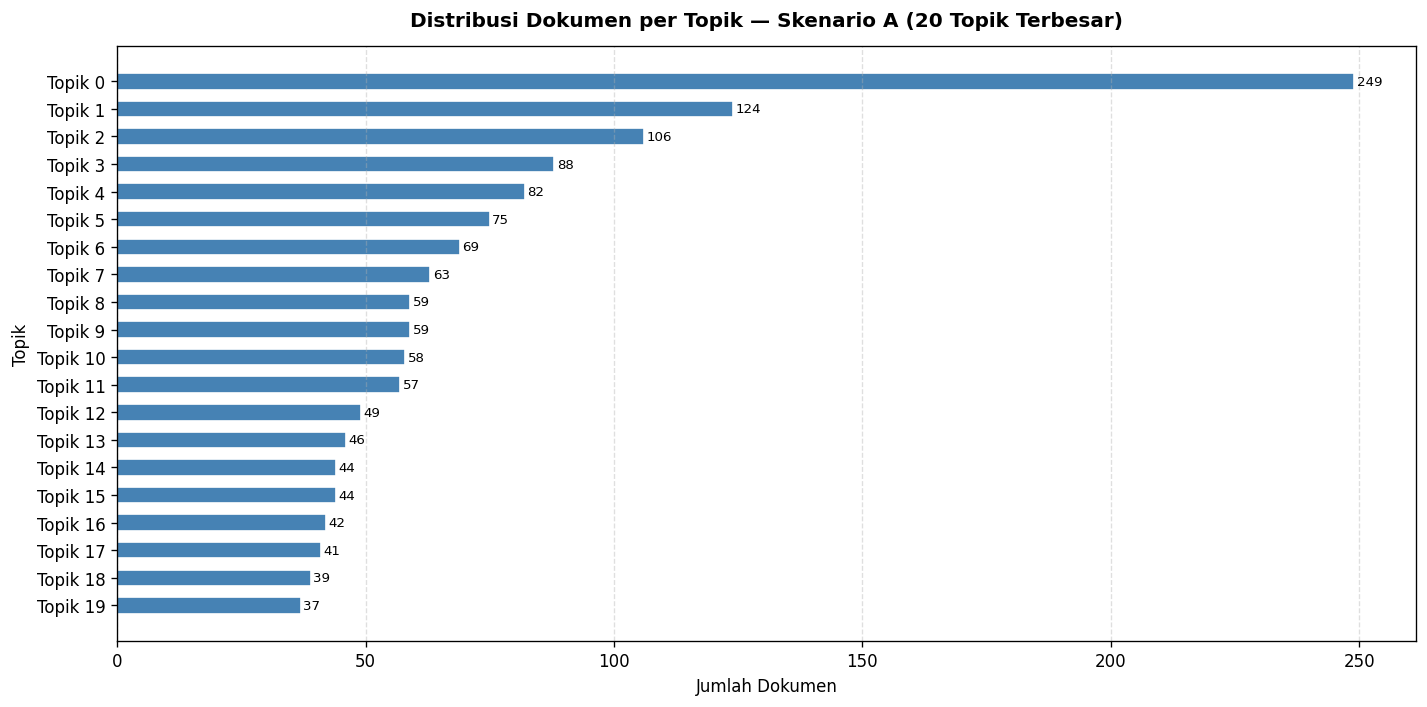

Visualisasi disimpan di: /Users/javierihsan/Javier/S1 UNAIR/skripsi/codingan_skripsi_javier/results/skenario_A/distribusi_topik_skenario_A.png


In [20]:
# Membuat bar chart distribusi jumlah dokumen per topik.
# Visualisasi ini memberikan gambaran keseimbangan antar topik
# dan membantu mengidentifikasi topik dominan dalam korpus.

info_valid = info_topik[info_topik["Topic"] != -1].copy()
info_valid = info_valid.sort_values("Count", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(
    [f"Topik {t}" for t in info_valid["Topic"]],
    info_valid["Count"],
    color="steelblue",
    edgecolor="white",
    height=0.6,
)

# Tambahkan label angka di ujung setiap bar
for bar, val in zip(bars, info_valid["Count"]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            str(val), va="center", ha="left", fontsize=8)

ax.set_title(
    "Distribusi Dokumen per Topik — Skenario A (20 Topik Terbesar)",
    fontsize=12, fontweight="bold", pad=12
)
ax.set_xlabel("Jumlah Dokumen", fontsize=10)
ax.set_ylabel("Topik", fontsize=10)
ax.invert_yaxis()
ax.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
path_viz_distrib = RESULTS_DIR / "distribusi_topik_skenario_A.png"
plt.savefig(path_viz_distrib, dpi=150, bbox_inches="tight")
plt.show()

print(f"Visualisasi disimpan di: {path_viz_distrib}")

In [21]:
# Membuat visualisasi interaktif bawaan BERTopic untuk melihat
# sebaran topik dalam ruang 2D. Visualisasi ini menggunakan
# Plotly dan akan terbuka sebagai HTML interaktif di browser.
# Simpan sebagai file HTML agar bisa dibuka ulang kapan saja.

try:
    fig_topik = topic_model_A.visualize_topics()
    path_html_topik = RESULTS_DIR / "peta_topik_skenario_A.html"
    fig_topik.write_html(str(path_html_topik))
    print(f"Peta topik interaktif disimpan di: {path_html_topik}")
    fig_topik.show()
except Exception as e:
    print(f"Visualisasi interaktif tidak dapat dibuat: {e}")
    print("Pastikan library plotly sudah terpasang: pip install plotly")

Peta topik interaktif disimpan di: /Users/javierihsan/Javier/S1 UNAIR/skripsi/codingan_skripsi_javier/results/skenario_A/peta_topik_skenario_A.html


In [22]:
# Membuat visualisasi barchart kata kunci bawaan BERTopic.
# Visualisasi ini menampilkan bobot c-TF-IDF dari kata-kata kunci
# terpenting untuk setiap topik dalam bentuk horizontal bar chart.

try:
    # Tampilkan 12 topik terbesar
    topik_ditampilkan = list(info_valid["Topic"].head(12))
    fig_barchart = topic_model_A.visualize_barchart(
        topics=topik_ditampilkan,
        top_n_topics=12,
        n_words=8,
    )
    path_html_bar = RESULTS_DIR / "barchart_kata_kunci_skenario_A.html"
    fig_barchart.write_html(str(path_html_bar))
    print(f"Barchart kata kunci disimpan di: {path_html_bar}")
    fig_barchart.show()
except Exception as e:
    print(f"Visualisasi barchart tidak dapat dibuat: {e}")

Barchart kata kunci disimpan di: /Users/javierihsan/Javier/S1 UNAIR/skripsi/codingan_skripsi_javier/results/skenario_A/barchart_kata_kunci_skenario_A.html


---
## 7. Menyimpan Hasil Model & Data Output

In [23]:
# Menyimpan model BERTopic Skenario A ke disk.
# Model yang tersimpan dapat dimuat kembali untuk inferensi dokumen baru
# atau untuk keperluan analisis lanjutan tanpa perlu melatih ulang.
# save_ctfidf=True menyertakan matriks c-TF-IDF agar representasi
# topik dapat dipulihkan sepenuhnya.

path_model_A = str(RESULTS_DIR / "model_bertopic_skenario_A")

topic_model_A.save(
    path_model_A,
    serialization="safetensors",
    save_ctfidf=True,
    save_embedding_model=NAMA_MODEL_EMBEDDING,
)

print(f"Model BERTopic Skenario A disimpan di:")
print(f"  {path_model_A}")

Model BERTopic Skenario A disimpan di:
  /Users/javierihsan/Javier/S1 UNAIR/skripsi/codingan_skripsi_javier/results/skenario_A/model_bertopic_skenario_A


In [24]:
# Menyimpan hasil penugasan topik ke setiap dokumen sebagai file CSV.
# File ini menggabungkan metadata dokumen asli dengan label topik
# yang diperoleh dari Skenario A, sehingga memudahkan analisis lanjutan
# dan perbandingan dengan hasil Skenario B.

df_hasil_A = df.copy()
df_hasil_A["topik_skenario_A"]       = topik
df_hasil_A["probabilitas_skenario_A"] = probabilitas.max(axis=1) if hasattr(probabilitas, 'ndim') and probabilitas.ndim > 1 else probabilitas

# Tambahkan label kata kunci topik untuk keterbacaan
def ambil_label_topik(id_topik: int) -> str:
    if id_topik == -1:
        return "outlier"
    kata = topic_model_A.get_topic(id_topik)
    if kata:
        return "_".join([w for w, _ in kata[:3]])
    return f"topik_{id_topik}"

df_hasil_A["label_topik_A"] = df_hasil_A["topik_skenario_A"].apply(ambil_label_topik)

path_hasil_A = RESULTS_DIR / "hasil_dokumen_skenario_A.csv"
df_hasil_A.to_csv(path_hasil_A, index=False, encoding="utf-8-sig")

print(f"Hasil penugasan topik disimpan di:")
print(f"  {path_hasil_A}")
print()
print("Pratinjau 5 baris:")
df_hasil_A[["advisory_id", "topik_skenario_A", "label_topik_A", "probabilitas_skenario_A"]].head()

Hasil penugasan topik disimpan di:
  /Users/javierihsan/Javier/S1 UNAIR/skripsi/codingan_skripsi_javier/results/skenario_A/hasil_dokumen_skenario_A.csv

Pratinjau 5 baris:


,advisory_id,topik_skenario_A,label_topik_A,probabilitas_skenario_A
0,ICSA-10-147-01,3,affected_siemens_access,1.000000
1,ICSA-10-316-01A,-1,outlier,0.000000
2,ICSA-10-322-01,-1,outlier,0.000000
3,ICSA-10-322-02A,-1,outlier,0.000000
4,ICSA-10-337-01,45,webaccess_advantech_broadwin,0.327331


In [25]:
# Menyimpan ringkasan informasi topik (topic info) ke file CSV terpisah.
# File ini berisi daftar semua topik, jumlah dokumen, dan representasi
# kata kunci — berguna sebagai tabel referensi pada laporan penelitian.

path_info_topik_A = RESULTS_DIR / "info_topik_skenario_A.csv"
info_topik.to_csv(path_info_topik_A, index=False, encoding="utf-8-sig")

print(f"Info topik disimpan di: {path_info_topik_A}")
print()
print("=" * 55)
print(" SKENARIO A SELESAI")
print("=" * 55)
print(f"  Jumlah topik terbentuk : {jumlah_topik_valid}")
print(f"  Dokumen terklaster     : {len(dokumen) - jumlah_outlier}")
print(f"  Dokumen outlier        : {jumlah_outlier}")
print()
print("File tersimpan di folder:")
print(f"  {RESULTS_DIR}")
print()
print("Lanjutkan ke notebook:")
print("  03_skenario_B_embedding_domain_spesifik.ipynb")

Info topik disimpan di: /Users/javierihsan/Javier/S1 UNAIR/skripsi/codingan_skripsi_javier/results/skenario_A/info_topik_skenario_A.csv

 SKENARIO A SELESAI
  Jumlah topik terbentuk : 62
  Dokumen terklaster     : 2233
  Dokumen outlier        : 1228

File tersimpan di folder:
  /Users/javierihsan/Javier/S1 UNAIR/skripsi/codingan_skripsi_javier/results/skenario_A

Lanjutkan ke notebook:
  03_skenario_B_embedding_domain_spesifik.ipynb
